In [1]:
from torch.utils.data import DataLoader
from PIL import Image
import os
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
import sys
sys.path.append("..")  # aggiunge la cartella padre (project/) al path
from data.dataset import MayoDataset, MayoDatasetNpy
from data.preprocessing import get_transform
import matplotlib.pyplot as plt
import random

In [2]:
print(os.getcwd())

# ============================================================
# CREATE DIRECTORY STRUCTURE
# ============================================================

BASE_DATA_PATH = "../data"

PREPROCESSED_PATH = os.path.join(BASE_DATA_PATH, "preprocessed")
SINOGRAM_CLEAN_PATH = os.path.join(BASE_DATA_PATH, "sinogram_clean")
SINOGRAM_CORRUPTED_PATH = os.path.join(BASE_DATA_PATH, "sinogram_corrupted")

splits = ["train", "validation", "test"]
angle_folders = ["angles_180", "angles_90", "angles_60", "angles_45"]

# ------------------------------------------------------------
# PREPROCESSED
# ------------------------------------------------------------
for split in splits:
    os.makedirs(
        os.path.join(PREPROCESSED_PATH, split),
        exist_ok=True
    )

# ------------------------------------------------------------
# SINOGRAMS
# ------------------------------------------------------------
for split in splits:

    for angle_folder in angle_folders:

        os.makedirs(
            os.path.join(
                SINOGRAM_CLEAN_PATH,
                split,
                angle_folder
            ),
            exist_ok=True
        )

        os.makedirs(
            os.path.join(
                SINOGRAM_CORRUPTED_PATH,
                split,
                angle_folder
            ),
            exist_ok=True
        )

print("Directory structure created.")
    
# ============================================================
# SAVE PREPROCESSED IMAGES
# ============================================================

def save_preprocessed_images(image_paths, split_name, transform):
    save_dir = os.path.join(PREPROCESSED_PATH, split_name)

    for img_path in image_paths:
        image = Image.open(img_path).convert("L")
        image_tensor = transform(image)
        image_np = image_tensor.squeeze().numpy()

        # crea nome univoco usando il path relativo rispetto a DATASET_PATH
        rel_path = os.path.relpath(img_path, DATASET_PATH)
        filename = rel_path.replace(os.sep, "_")
        filename = os.path.splitext(filename)[0] + ".npy"

        save_path = os.path.join(save_dir, filename)
        np.save(save_path, image_np)

    print(f"Saved {split_name}: {len(image_paths)} immagini")

DATASET_PATH = "../data/raw"

all_images = glob(
    os.path.join(DATASET_PATH, "**", "*.png"),
    recursive=True
)

print("Found images:", len(all_images))

train_images_raw, temp_images_raw = train_test_split(
    all_images,
    test_size=0.3,
    random_state=42
)

val_images_raw, test_images_raw = train_test_split(
    temp_images_raw,
    test_size=0.5,
    random_state=42
)

transform = get_transform()

# ============================================================
# SAVE PREPROCESSED DATASET
# ============================================================

save_preprocessed_images(train_images_raw, "train", transform)
save_preprocessed_images(val_images_raw, "validation", transform)
save_preprocessed_images(test_images_raw, "test", transform)


print(f"Totale immagini:    {len(all_images)}")
print(f"Train:              {len(train_images_raw)} ({len(train_images_raw
)/len(all_images)*100:.1f}%)")
print(f"Validation:         {len(val_images_raw)} ({len(val_images_raw)/len(all_images)*100:.1f}%)")
print(f"Test:               {len(test_images_raw)} ({len(test_images_raw)/len(all_images)*100:.1f}%)")

/home/extter/sparse_mayo/notebooks
Directory structure created.
Found images: 3633
Saved train: 2543 immagini
Saved validation: 545 immagini
Saved test: 545 immagini
Totale immagini:    3633
Train:              2543 (70.0%)
Validation:         545 (15.0%)
Test:               545 (15.0%)


In [3]:
PREPROCESSED_PATH = "../data/preprocessed"

train_images_npy = glob(os.path.join(PREPROCESSED_PATH, "train", "*.npy"))
val_images_npy   = glob(os.path.join(PREPROCESSED_PATH, "validation", "*.npy"))
test_images_npy  = glob(os.path.join(PREPROCESSED_PATH, "test", "*.npy"))

train_loader = DataLoader(MayoDatasetNpy(train_images_npy), batch_size=8, shuffle=True)
val_loader   = DataLoader(MayoDatasetNpy(val_images_npy),   batch_size=8, shuffle=False)
test_loader  = DataLoader(MayoDatasetNpy(test_images_npy),  batch_size=8, shuffle=False)

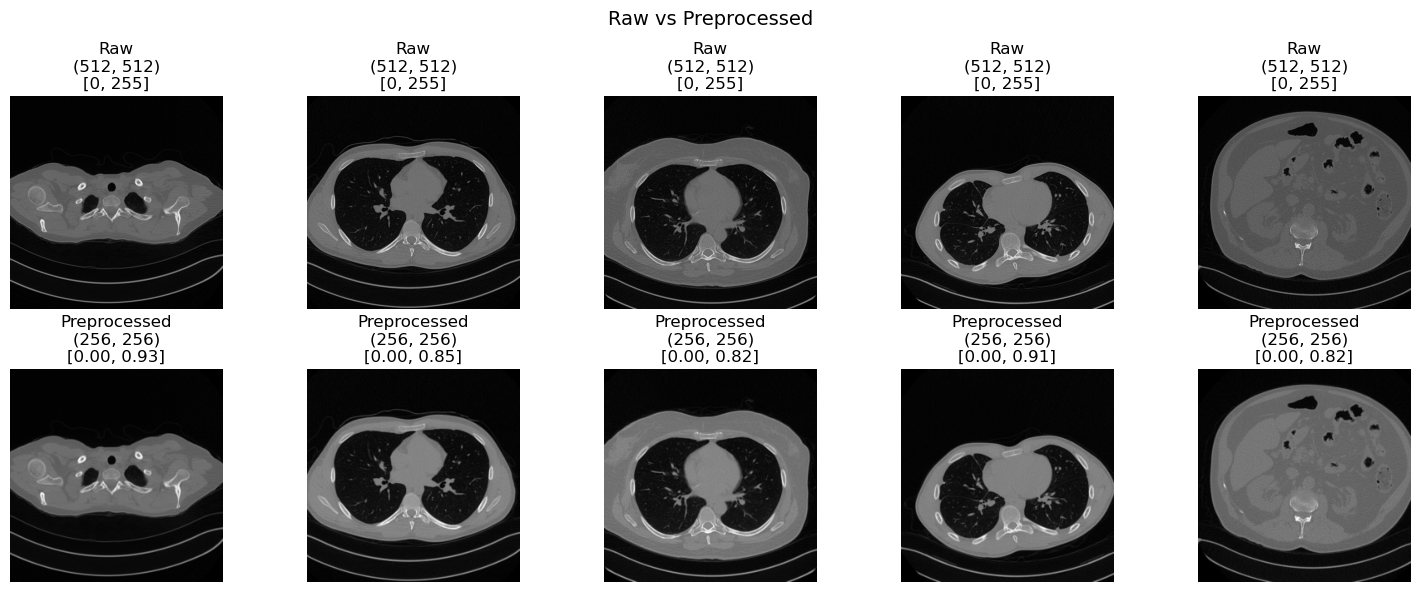

In [4]:

def show_raw_vs_preprocessed(raw_path, transform, n=5):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    
    sample_paths = random.sample(raw_path, n)
    
    for i, path in enumerate(sample_paths):
        # raw
        raw = Image.open(path).convert("L")
        axes[0, i].imshow(raw, cmap="gray")
        axes[0, i].set_title(f"Raw\n{np.array(raw).shape}\n[{np.array(raw).min()}, {np.array(raw).max()}]")
        axes[0, i].axis("off")
        
        # preprocessata
        tensor = transform(raw).squeeze().numpy()
        axes[1, i].imshow(tensor, cmap="gray")
        axes[1, i].set_title(f"Preprocessed\n{tensor.shape}\n[{tensor.min():.2f}, {tensor.max():.2f}]")
        axes[1, i].axis("off")
    
    plt.suptitle("Raw vs Preprocessed", fontsize=14)
    plt.tight_layout()
    plt.show()

show_raw_vs_preprocessed(train_images_raw, transform)

=== DATASET SPLIT ===
Totale immagini:  3633
Train:            2543 (70.0%)
Validation:       545 (15.0%)
Test:             545 (15.0%)

=== FILE .NPY SALVATI ===
Train .npy:       2543
Validation .npy:  545
Test .npy:        545

=== TYPE & SHAPE CHECK (.npy) ===
Tipo:             <class 'numpy.ndarray'>
Shape:            (256, 256)
Dtype:            float32
Min value:        0.0000
Max value:        0.8667
Valori in [0,1]:  True

=== BATCH CHECK ===
Shape batch:      torch.Size([8, 1, 256, 256])
Dtype batch:      torch.float32
Min batch:        0.0000
Max batch:        0.9333

=== DIMENSIONI ORIGINALI (prime 5 immagini raw) ===
  240.png                                  → 512x512 px
  271.png                                  → 512x512 px
  99.png                                   → 512x512 px
  16.png                                   → 512x512 px
  38.png                                   → 512x512 px


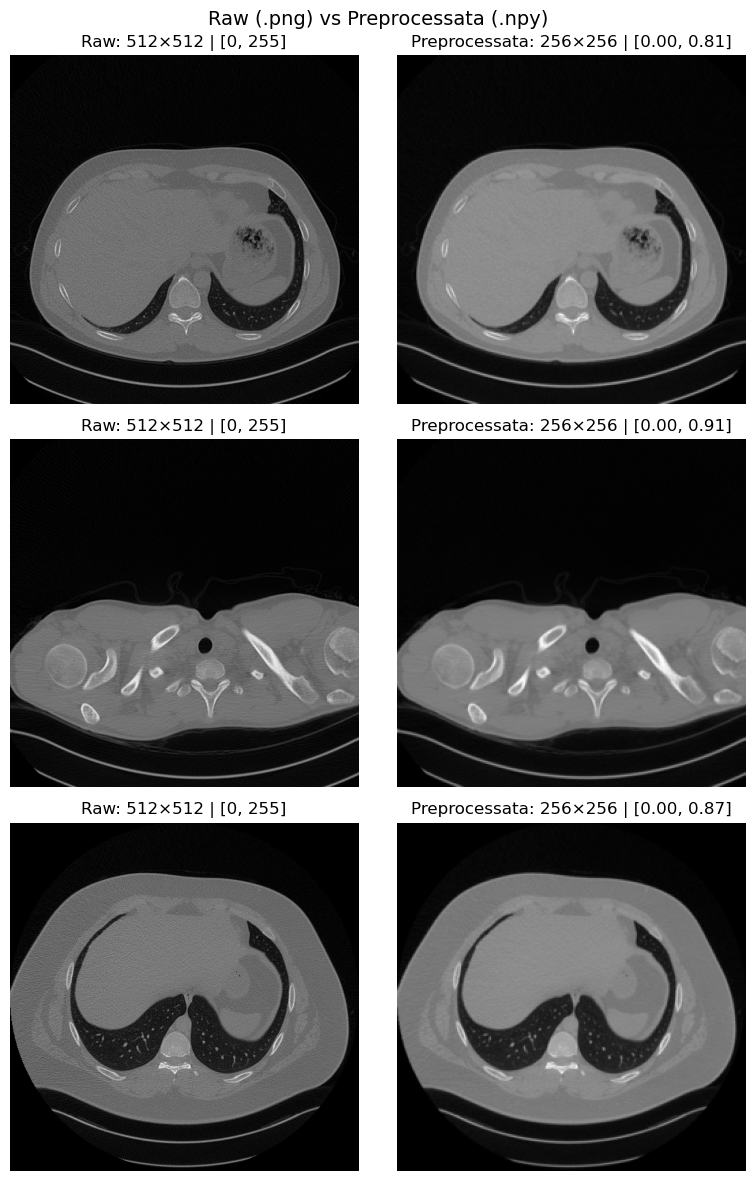

In [5]:

# ============================================================
# CHECK 1: Distribuzione del dataset
# ============================================================
print("=== DATASET SPLIT ===")
print(f"Totale immagini:  {len(all_images)}")
print(f"Train:            {len(train_images_raw)} ({len(train_images_raw)/len(all_images)*100:.1f}%)")
print(f"Validation:       {len(val_images_raw)} ({len(val_images_raw)/len(all_images)*100:.1f}%)")
print(f"Test:             {len(test_images_raw)} ({len(test_images_raw)/len(all_images)*100:.1f}%)")

# ============================================================
# CHECK 2: Verifica file .npy salvati
# ============================================================
print("\n=== FILE .NPY SALVATI ===")
print(f"Train .npy:       {len(train_images_npy)}")
print(f"Validation .npy:  {len(val_images_npy)}")
print(f"Test .npy:        {len(test_images_npy)}")

# ============================================================
# CHECK 3: Shape, dtype e range di un campione .npy
# ============================================================
print("\n=== TYPE & SHAPE CHECK (.npy) ===")
sample_np = np.load(train_images_npy[0])
print(f"Tipo:             {type(sample_np)}")
print(f"Shape:            {sample_np.shape}")           # atteso: (256, 256)
print(f"Dtype:            {sample_np.dtype}")           # atteso: float32
print(f"Min value:        {sample_np.min():.4f}")       # atteso: >= 0.0
print(f"Max value:        {sample_np.max():.4f}")       # atteso: <= 1.0
print(f"Valori in [0,1]:  {(sample_np >= 0).all() and (sample_np <= 1).all()}")

# ============================================================
# CHECK 4: Verifica batch dal DataLoader
# ============================================================
print("\n=== BATCH CHECK ===")
batch = next(iter(train_loader))
print(f"Shape batch:      {batch.shape}")    # atteso: [8, 1, 256, 256]
print(f"Dtype batch:      {batch.dtype}")    # atteso: torch.float32
print(f"Min batch:        {batch.min():.4f}")
print(f"Max batch:        {batch.max():.4f}")

# ============================================================
# CHECK 5: Dimensioni originali (raw .png)
# ============================================================
print("\n=== DIMENSIONI ORIGINALI (prime 5 immagini raw) ===")
for path in train_images_raw[:5]:
    img = Image.open(path).convert("L")
    print(f"  {os.path.basename(path):40s} → {img.size[0]}x{img.size[1]} px")

# ============================================================
# CHECK 6: Visualizza raw vs preprocessata (.npy)
# ============================================================
# CHECK 6: Visualizza raw vs preprocessata (.npy)
n = 3
fig, axes = plt.subplots(n, 2, figsize=(8, 4*n))
fig.suptitle("Raw (.png) vs Preprocessata (.npy)", fontsize=14)

samples_raw = random.sample(train_images_raw, n)

for i, raw_path in enumerate(samples_raw):
    # ricostruisce il nome .npy con lo stesso metodo usato nel salvataggio
    rel_path = os.path.relpath(raw_path, DATASET_PATH)
    filename_npy = rel_path.replace(os.sep, "_")
    filename_npy = os.path.splitext(filename_npy)[0] + ".npy"
    npy_path = os.path.join(PREPROCESSED_PATH, "train", filename_npy)

    # raw
    img_raw = Image.open(raw_path).convert("L")
    axes[i, 0].imshow(img_raw, cmap="gray")
    axes[i, 0].set_title(f"Raw: {img_raw.size[0]}×{img_raw.size[1]} | [{np.array(img_raw).min()}, {np.array(img_raw).max()}]")
    axes[i, 0].axis("off")

    # preprocessata
    img_npy = np.load(npy_path)
    axes[i, 1].imshow(img_npy, cmap="gray")
    axes[i, 1].set_title(f"Preprocessata: 256×256 | [{img_npy.min():.2f}, {img_npy.max():.2f}]")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()
